# Facial Expression Model - Training and Evaluation


Dataset: FER-2013 from Kaggle: https://www.kaggle.com/datasets/msambare/fer2013

Important: the labels describe dataset categories and model predictions. They are not proof of a person's true feelings, confidence, nervousness, honesty or suitability for a job.

## 1. Import the required libraries

In [1]:
import glob
import json
import os
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from tensorflow.keras.applications import Xception
from tensorflow.keras.applications.xception import preprocess_input
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Input
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.utils import image_dataset_from_directory, set_random_seed

warnings.filterwarnings("ignore")

## 2. Reproducibility

In [2]:
seed = 100
random.seed(seed)
np.random.seed(seed)
set_random_seed(seed)

## 3. Attach the FER-2013 dataset


In [3]:
DATA_DIR = "/kaggle/input/datasets/msambare/fer2013"
TRAIN_DIR = DATA_DIR + "/train"
TEST_DIR = DATA_DIR + "/test"

train_image_paths = glob.glob(TRAIN_DIR + "/*/*")
test_image_paths = glob.glob(TEST_DIR + "/*/*")

print("Training images:", len(train_image_paths))
print("Testing images:", len(test_image_paths))

Training images: 28709
Testing images: 7178


## 4. Exploratory data analysis and class balance

,train,test
angry,3995,958
disgust,436,111
fear,4097,1024
happy,7215,1774
neutral,4965,1233
sad,4830,1247
surprise,3171,831


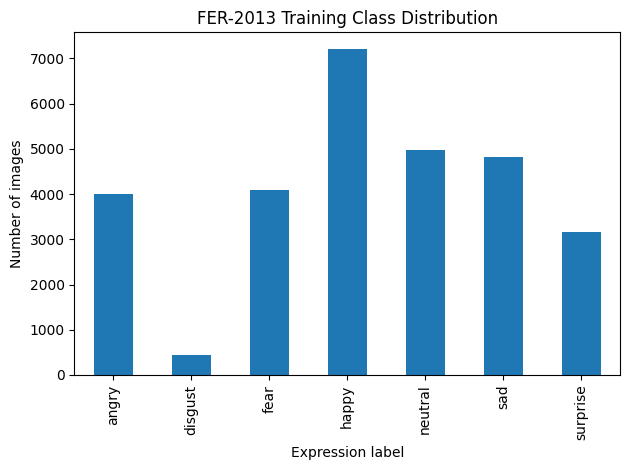

In [4]:
train_labels = [path.split('/')[-2] for path in train_image_paths]
test_labels = [path.split('/')[-2] for path in test_image_paths]

train_counts = pd.Series(train_labels).value_counts().sort_index()
test_counts = pd.Series(test_labels).value_counts().sort_index()

display(pd.DataFrame({"train": train_counts, "test": test_counts}))
train_counts.plot(kind="bar", title="FER-2013 Training Class Distribution")
plt.xlabel("Expression label")
plt.ylabel("Number of images")
plt.tight_layout()
plt.savefig("/kaggle/working/class_distribution.png")
plt.show()

## 5. Create train, validation and test datasets

In [5]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_ds = image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.20,
    subset="training",
    seed=seed,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds = image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.20,
    subset="validation",
    seed=seed,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
class_names

Found 28709 files belonging to 7 classes.
Using 22968 files for training.


I0000 00:00:1787655286.504839     790 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1787655286.507039     790 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 28709 files belonging to 7 classes.
Using 5741 files for validation.
Found 7178 files belonging to 7 classes.


['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

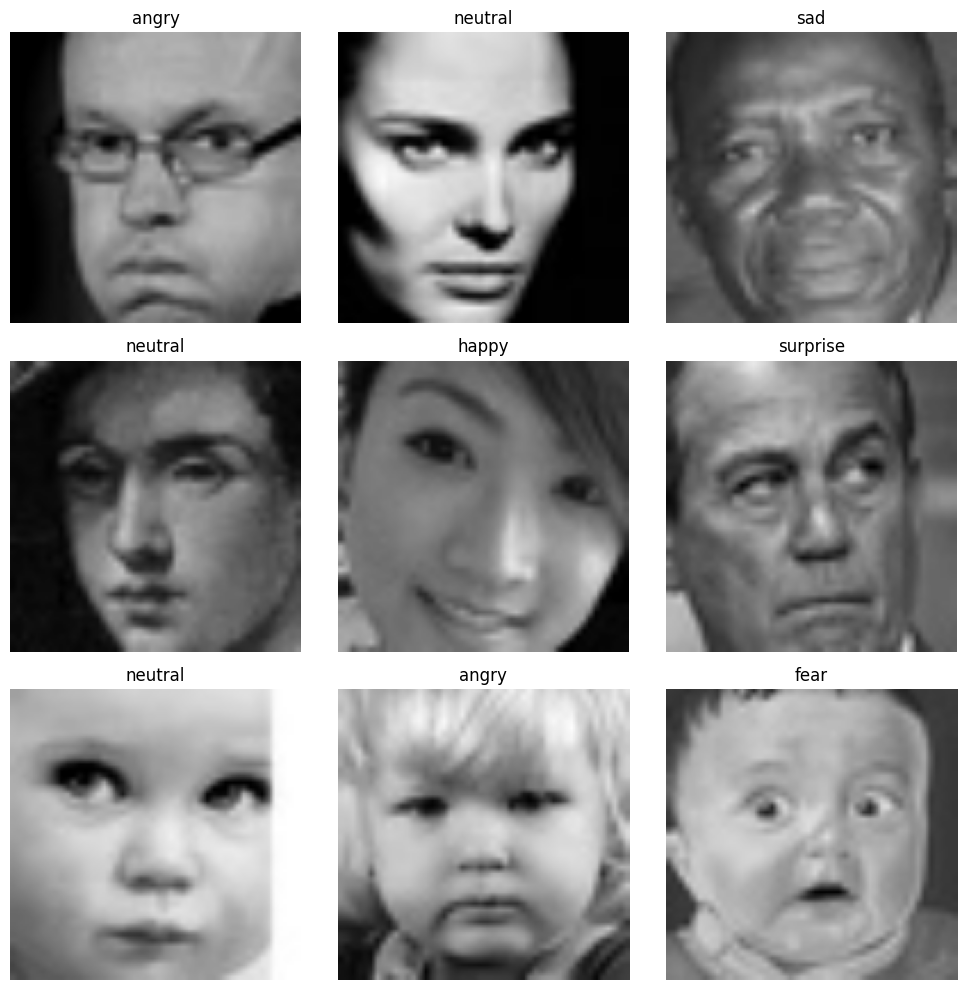

In [6]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.tight_layout()
plt.savefig("/kaggle/working/sample_images.png")
plt.show()

## 6. Build the transfer-learning model


In [7]:
backbone = Xception(
    include_top=False,
    weights="imagenet",
    input_shape=(128, 128, 3)
)
backbone.trainable = False

inputs = Input(shape=(128, 128, 3))
x = preprocess_input(inputs)
x = backbone(x)
x = GlobalAveragePooling2D()(x)
outputs = Dense(len(class_names), activation="softmax")(x)

model = Model(inputs=inputs, outputs=outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ xception (Functional)           │ (None, 4, 4, 2048)     │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │        14,343 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,875,823 (79.63 MB)

 Trainable params: 14,343 (56.03 KB)

 Non-trainable params: 20,861,480 (79.58 MB)

## 7. Compile and train with a validation checkpoint

In [8]:
checkpoint_filepath = "/kaggle/working/face_expression_model.keras"

model_checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_filepath,
    monitor="val_accuracy",
    save_weights_only=False,
    mode="max",
    save_best_only=True
)

model.compile(
    loss="sparse_categorical_crossentropy",
    metrics=["acc"]
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    batch_size=BATCH_SIZE,
    callbacks=[model_checkpoint_callback]
)

Epoch 1/30


2026-08-25 10:55:05.786529: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-25 10:55:05.933179: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-25 10:55:06.892783: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-25 10:55:07.027230: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-25 10:55:07.890464: E external/local_xla/xla/stream_

716/718 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - acc: 0.3862 - loss: 1.5866

2026-08-25 10:55:44.787257: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-25 10:55:44.931548: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-25 10:55:45.075144: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-25 10:55:45.982754: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-25 10:55:46.118469: E external/local_xla/xla/stream_

718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - acc: 0.3863 - loss: 1.5864

2026-08-25 10:56:07.041444: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-25 10:56:07.181154: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-25 10:56:07.971155: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-25 10:56:08.105050: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-25 10:56:08.906545: E external/local_xla/xla/stream_

718/718 ━━━━━━━━━━━━━━━━━━━━ 77s 86ms/step - acc: 0.4222 - loss: 1.5211 - val_acc: 0.5675 - val_loss: 1.2539
Epoch 2/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 37s 51ms/step - acc: 0.4749 - loss: 1.3995 - val_acc: 0.5060 - val_loss: 1.3023
Epoch 3/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 39s 55ms/step - acc: 0.4955 - loss: 1.3456 - val_acc: 0.5577 - val_loss: 1.2671
Epoch 4/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 40s 56ms/step - acc: 0.5125 - loss: 1.3118 - val_acc: 0.6027 - val_loss: 1.1964
Epoch 5/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 45s 63ms/step - acc: 0.5211 - loss: 1.2855 - val_acc: 0.4903 - val_loss: 1.3272
Epoch 6/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 37s 52ms/step - acc: 0.5319 - loss: 1.2653 - val_acc: 0.5365 - val_loss: 1.3091
Epoch 7/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 37s 52ms/step - acc: 0.5397 - loss: 1.2486 - val_acc: 0.5874 - val_loss: 1.1717
Epoch 8/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 37s 52ms/step - acc: 0.5441 - loss: 1.2330 - val_acc: 0.5147 - val_loss: 1.3010
Epoch 9/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 37s 52ms/st

In [15]:
monitor="val_acc"
save_best_only=True

## 8. Plot and save the training curves

,acc,loss,val_acc,val_loss
0,0.422196,1.521086,0.567497,1.253904
1,0.474922,1.399544,0.506009,1.302295
2,0.495515,1.345645,0.557743,1.267067
3,0.512496,1.311782,0.602682,1.196410
4,0.521116,1.285481,0.490333,1.327184
5,0.531870,1.265282,0.536492,1.309079
6,0.539664,1.248565,0.587354,1.171713
7,0.544105,1.232968,0.514719,1.301016
8,0.548241,1.220286,0.555478,1.236845
9,0.555643,1.208287,0.527260,1.304753


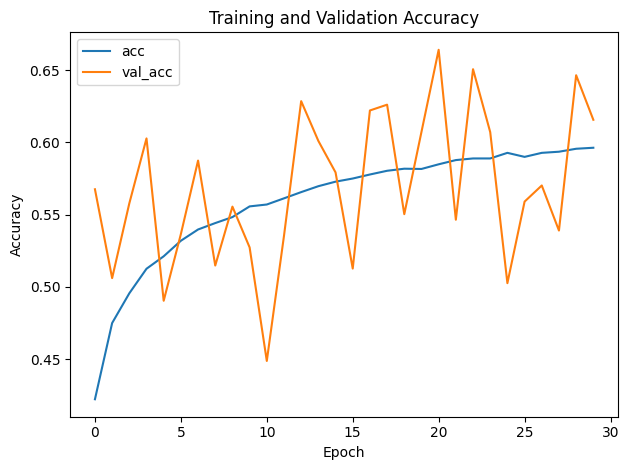

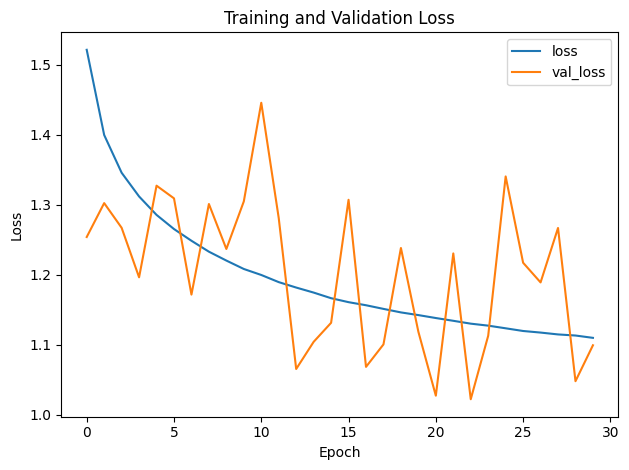

In [9]:
history_df = pd.DataFrame(history.history)
display(history_df)

history_df[["acc", "val_acc"]].plot(title="Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.tight_layout()
plt.savefig("/kaggle/working/accuracy_curve.png")
plt.show()

history_df[["loss", "val_loss"]].plot(title="Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.tight_layout()
plt.savefig("/kaggle/working/loss_curve.png")
plt.show()

## 9. Evaluate the best model on untouched test data

In [10]:
best_model = load_model(checkpoint_filepath)
test_loss, test_accuracy = best_model.evaluate(test_ds)
print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

224/225 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - acc: 0.3975 - loss: 1.7899

2026-08-25 11:14:54.731461: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-25 11:14:54.871075: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-25 11:14:55.655805: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-25 11:14:55.789920: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-25 11:14:56.597448: E external/local_xla/xla/stream_

225/225 ━━━━━━━━━━━━━━━━━━━━ 27s 99ms/step - acc: 0.4866 - loss: 1.5238
Test loss: 1.5238038301467896
Test accuracy: 0.4866257905960083


In [11]:
y_test = np.concatenate([labels.numpy() for images, labels in test_ds])
y_probability = best_model.predict(test_ds)
y_pred = np.argmax(y_probability, axis=1)

majority_class = np.bincount(y_test.astype(int)).argmax()
baseline_pred = np.full_like(y_test, majority_class)
baseline_accuracy = accuracy_score(y_test, baseline_pred)
model_accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")

print("Majority-class baseline accuracy:", baseline_accuracy)
print("Model accuracy:", model_accuracy)
print("Macro F1-score:", macro_f1)
print(classification_report(y_test, y_pred, target_names=class_names))

225/225 ━━━━━━━━━━━━━━━━━━━━ 17s 59ms/step
Majority-class baseline accuracy: 0.24714405126776262
Model accuracy: 0.4866258010587908
Macro F1-score: 0.42563368953779285
              precision    recall  f1-score   support

       angry       0.39      0.27      0.32       958
     disgust       0.27      0.16      0.20       111
        fear       0.39      0.28      0.33      1024
       happy       0.66      0.71      0.68      1774
     neutral       0.41      0.54      0.46      1233
         sad       0.40      0.38      0.39      1247
    surprise       0.56      0.64      0.60       831

    accuracy                           0.49      7178
   macro avg       0.44      0.43      0.43      7178
weighted avg       0.48      0.49      0.48      7178



## 10. Confusion matrix

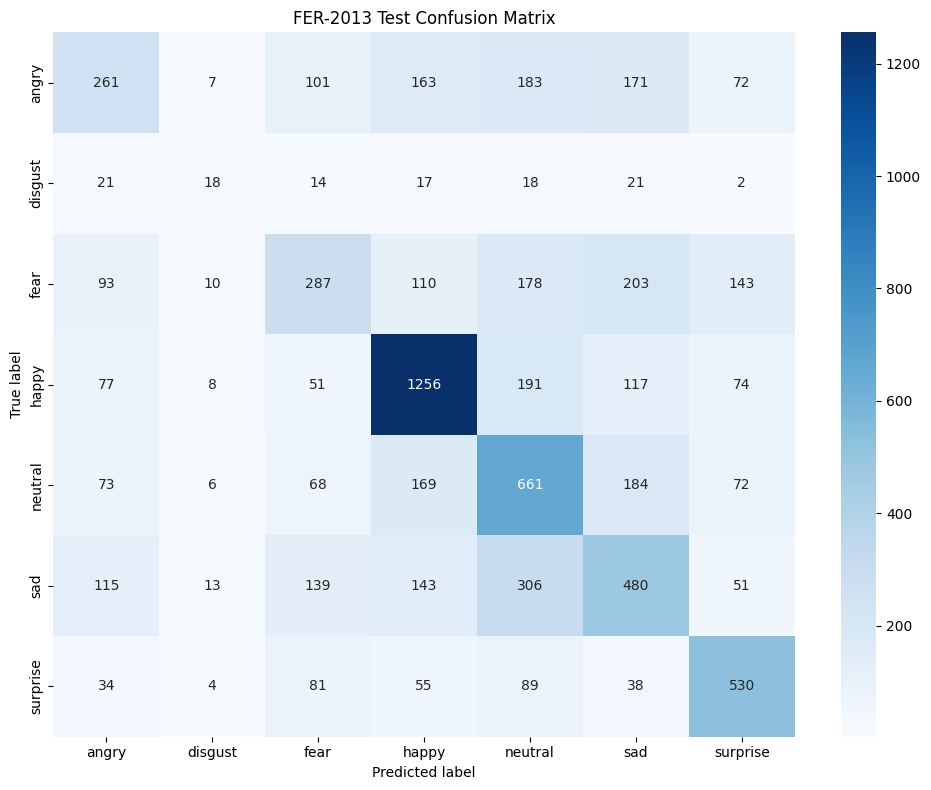

In [12]:
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    conf_matrix,
    annot=True,
    cmap="Blues",
    fmt="g",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("FER-2013 Test Confusion Matrix")
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix.png")
plt.show()

## 11. Qualitative error analysis

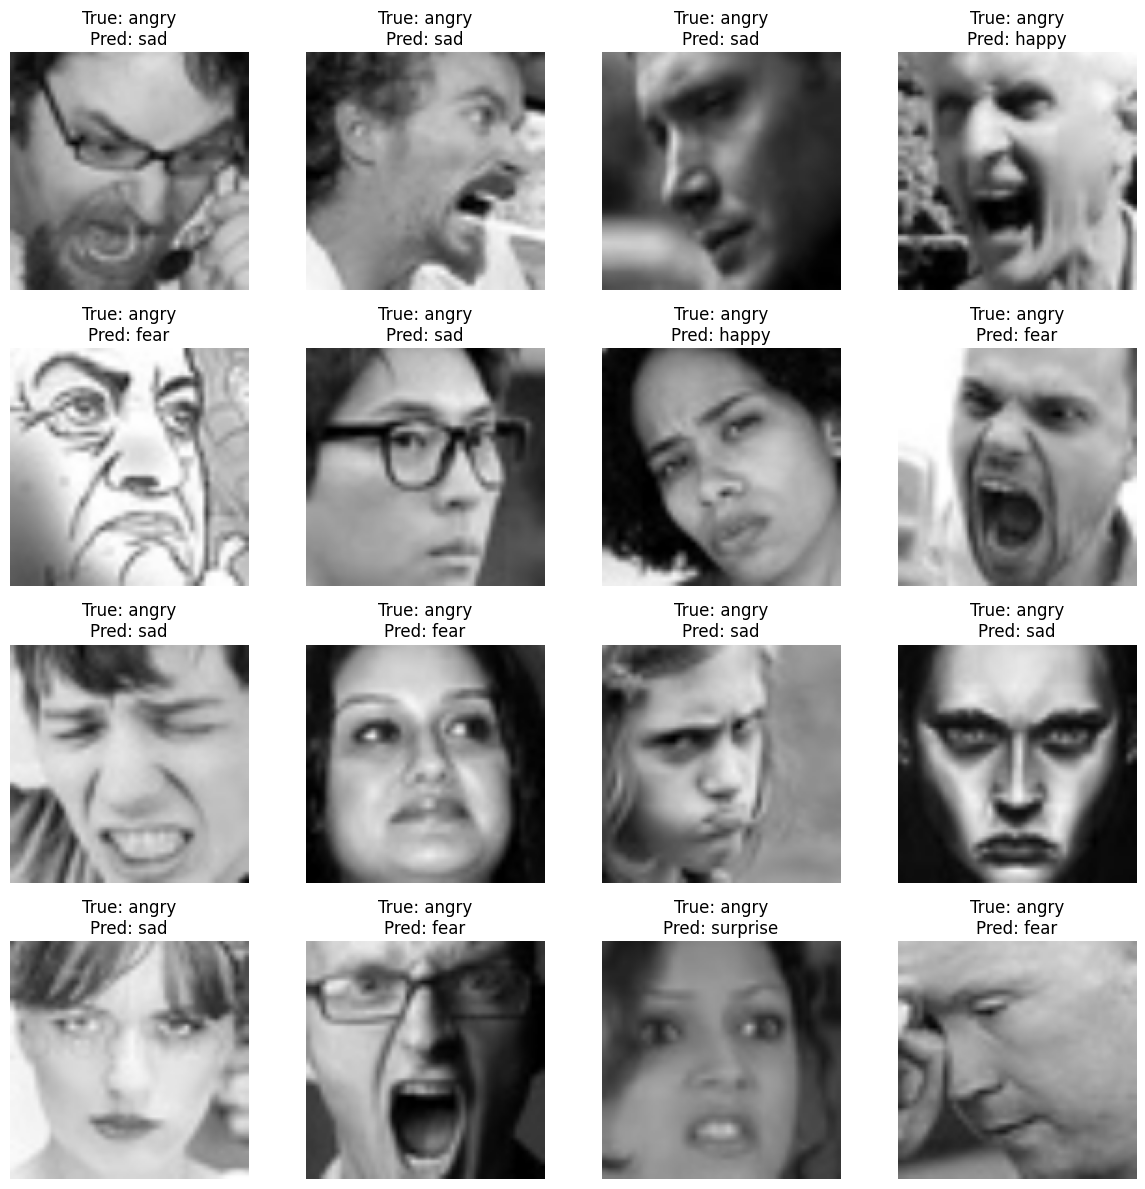

In [13]:
test_images = np.concatenate([images.numpy() for images, labels in test_ds])
wrong_indices = np.where(y_test != y_pred)[0]

plt.figure(figsize=(12, 12))
for i, image_index in enumerate(wrong_indices[:16]):
    plt.subplot(4, 4, i + 1)
    plt.imshow(test_images[image_index].astype("uint8"))
    true_name = class_names[int(y_test[image_index])]
    predicted_name = class_names[int(y_pred[image_index])]
    plt.title(f"True: {true_name}\nPred: {predicted_name}")
    plt.axis("off")
plt.tight_layout()
plt.savefig("/kaggle/working/error_examples.png")
plt.show()

### Error-analysis questions to answer after running

1. Which two expression classes are confused most often?
2. Are darker, side-facing, covered or low-resolution faces harder?
3. Does class imbalance explain part of the error?
4. Are some labels visually ambiguous even for a human?
5. How might demographic and cultural representation affect generalisation?

## 12. Save the model, labels and results for the application

In [14]:
with open("/kaggle/working/class_names.json", "w") as class_file:
    json.dump(class_names, class_file)

results = {
    "majority_baseline_accuracy": float(baseline_accuracy),
    "test_loss": float(test_loss),
    "test_accuracy": float(test_accuracy),
    "macro_f1": float(macro_f1),
    "number_of_test_images": int(len(y_test)),
    "class_names": class_names
}

with open("/kaggle/working/evaluation_results.json", "w") as result_file:
    json.dump(results, result_file, indent=2)

print("Download these files from Kaggle Output:")
print("face_expression_model.keras")
print("class_names.json")
print("evaluation_results.json")
print("accuracy_curve.png, loss_curve.png, confusion_matrix.png, error_examples.png")

Download these files from Kaggle Output:
face_expression_model.keras
class_names.json
evaluation_results.json
accuracy_curve.png, loss_curve.png, confusion_matrix.png, error_examples.png
